In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('clean_jobvision.csv')

In [23]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
df.head(2)

,Jobpost_RawTitle,Jobpost_PreferredGender,Jobpost_ProvinceFa,Jobpost_WorkTypeFa,Jobpost_SalaryCanBeShown,Jobpost_MinSalary,Jobpost_MaxSalary,Jobpost_MainJobCategory,Jobpost_SecondaryJobCategories,Jobpost_IndustryFa,Jobpost_RequiredExperienceYears,Jobpost_RequiredRelatedExperienceInThisIndustry,Jobpost_CompanyWorkTimesDescription,Jobpost_LanguageSkills,Jobpost_SoftwareSkills,Jobpost_AcademicFields,Jobpost_BenefitFa,Jobpost_HasDisabilitySupport,Jobpost_RequiredMinAge,Jobpost_RequiredMaxAge,Jobpost_RequiredMilitaryServiceCard,Jobpost_IsRemote,Jobpost_IsInternship,Jobpost_PriorityWithLocalCandidate,Jobpost_ActivationTime_YEAR_MONTH,Company_AgeFromEstablishmentYear,Company_ProvinceFa,Company_CityFa,Comany_CompanyOwnershipTypesFa,Company_SizeFa,Company_SizeEn,Company_ActivityTypeFa,Company_IndustryFa,HasAcademicField,HasBenefit,Jobpost_RawTitle_Clean,Jobpost_RawTitle_Clean_Language,salary_status,Jobpost_Group,langs,levels_lang,first_skill,all_skills,all_skills_levels,academic,degree,بیمه تکمیلی,ساعت منعطف,دورکاری,پاداش,وام,آموزش,همه_مزایا,salary_mean
0,مهندس مکانیک,تفاوتی ندارد,تهران,پاره وقت,False,10.0,12.0,مهندسی مکانیک / مهندسی هوا و فضا,نامشخص,تولیدی / صنعتی,1,False,نیمه وقت,نامشخص,نامشخص,"[{""FieldType"":""مهندسی مکانیک"",""DegreeLevel"":""کارشناسی""}]",نامشخص,False,25.0,35.0,False,False,False,False,2022-04,more than 20 years,تهران,تهران,خصوصی,11 تا 50 نفر,11 - 50 employees,شرکت ایرانی دارای مشتریان داخلی,"ساختمان / مصالح و تجهیزات ساختمانی,تولیدی / صنعتی",True,False,مهندس مکانیک,Farsi,توافقی,مهندسی و فنی,نامشخص,نامشخص,نامشخص,نامشخص,نامشخص,مهندسی مکانیک,کارشناسی,0,0,0,0,0,0,نامشخص,11.0
1,طراح و گرافیست,تفاوتی ندارد,تهران,تمام وقت,False,10.0,12.0,طراحی گرافیک / طراحی انیمیشن و موشن گرافیک,نامشخص,طراحی / گرافیک / هنر,3,False,تمام وقت,نامشخص,"[{""TitleFa"":""ایلاستریتور,ایلوستریتور"",""TitleEn"":""Adobe Illustrator"",""Level"":""متوسط""},{""TitleFa"":""ایندیزاین,این دیزاین"",""TitleEn"":""Adobe Indesign"",""Level"":""متوسط""},{""TitleFa"":""پریمیر"",""TitleEn"":""Adobe Premiere"",""Level"":""متوسط""},{""TitleFa"":""فتوشاپ,فوتوشاپ"",""TitleEn"":""Adobe Photoshop"",""Level"":""متوسط""},{""TitleFa"":""کورل,کرل"",""TitleEn"":""Corel Draw"",""Level"":""متوسط""}]","[{""FieldType"":""هنر"",""DegreeLevel"":""کارشناسی""}]",نامشخص,False,23.0,33.0,False,False,False,True,2023-03,10 - 14 years,تهران,تهران,خصوصی,11 تا 50 نفر,11 - 50 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,طراحی / گرافیک / هنر,True,False,طراح و گرافیست,Farsi,توافقی,طراحی و هنر,نامشخص,نامشخص,"ایلاستریتور,ایلوستریتور","ایلاستریتور,ایلوستریتور, ایندیزاین,این دیزاین, پریمیر, فتوشاپ,فوتوشاپ, کورل,کرل","متوسط, متوسط, متوسط, متوسط, متوسط",هنر,کارشناسی,0,0,0,0,0,0,نامشخص,11.0


In [5]:
numeric_cols = ["Jobpost_MinSalary", "Jobpost_MaxSalary",
                "Jobpost_RequiredExperienceYears",
                "Jobpost_RequiredMinAge", "Jobpost_RequiredMaxAge"]

In [12]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

خلاصه آماری ستون های عددی........................................................................................................................................................

In [7]:
df[numeric_cols].describe()

,Jobpost_MinSalary,Jobpost_MaxSalary,Jobpost_RequiredExperienceYears,Jobpost_RequiredMinAge,Jobpost_RequiredMaxAge
count,364838.000000,364838.000000,364838.000000,364838.000000,364838.000000
mean,10.589190,13.010947,2.174957,23.759956,37.838696
std,3.645994,4.993223,1.890549,3.268021,4.745949
min,2.000000,3.000000,0.000000,18.000000,18.000000
25%,10.000000,12.000000,1.000000,22.000000,35.000000
50%,10.000000,12.000000,2.000000,24.000000,37.000000
75%,10.000000,12.000000,3.000000,25.000000,40.000000
max,70.000000,100.000000,30.000000,50.000000,60.000000


array([[<Axes: title={'center': 'Jobpost_MinSalary'}>,
        <Axes: title={'center': 'Jobpost_MaxSalary'}>]], dtype=object)

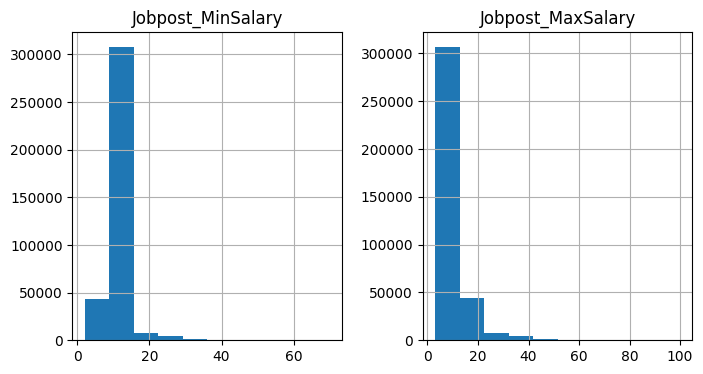

In [8]:
df[['Jobpost_MinSalary', 'Jobpost_MaxSalary']].hist(figsize=(8,4))

حداقل و حداکثر درآمد بر حسب شهرها .........................................................................................................................

In [9]:
df.groupby('Jobpost_ProvinceFa')[['Jobpost_MinSalary', 'Jobpost_MaxSalary']].mean()

,Jobpost_MinSalary,Jobpost_MaxSalary
Jobpost_ProvinceFa,,
آذربایجان شرقی,10.622543,13.101105
آذربایجان غربی,10.696437,13.220595
اردبیل,10.696916,13.223789
اصفهان,10.355927,12.698843
البرز,10.485224,12.848285
ایلام,11.007102,13.683239
بوشهر,11.492253,14.274732
تهران,10.611034,13.035031
خارج کشور,15.793313,20.057751


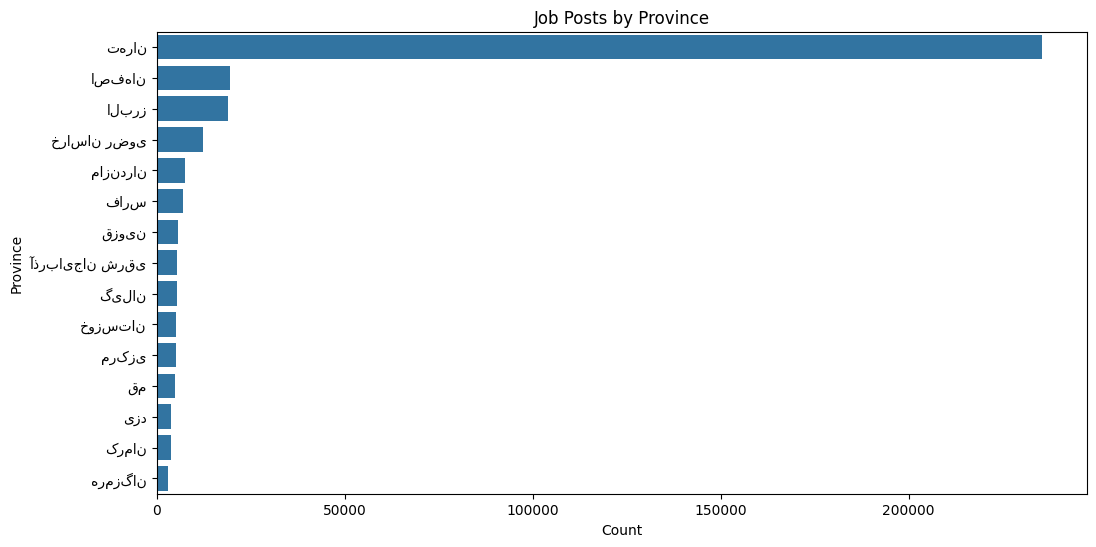

In [ ]:
plt.figure(figsize=(12,6))
province_counts = df['Jobpost_ProvinceFa'].value_counts().head(15)
plt.rcParams['font.family'] = 'Tahoma'

sns.barplot(x=province_counts.values, y=province_counts.index)
plt.title("Job Posts by Province")
plt.xlabel("Count")
plt.ylabel("Province")
plt.show()

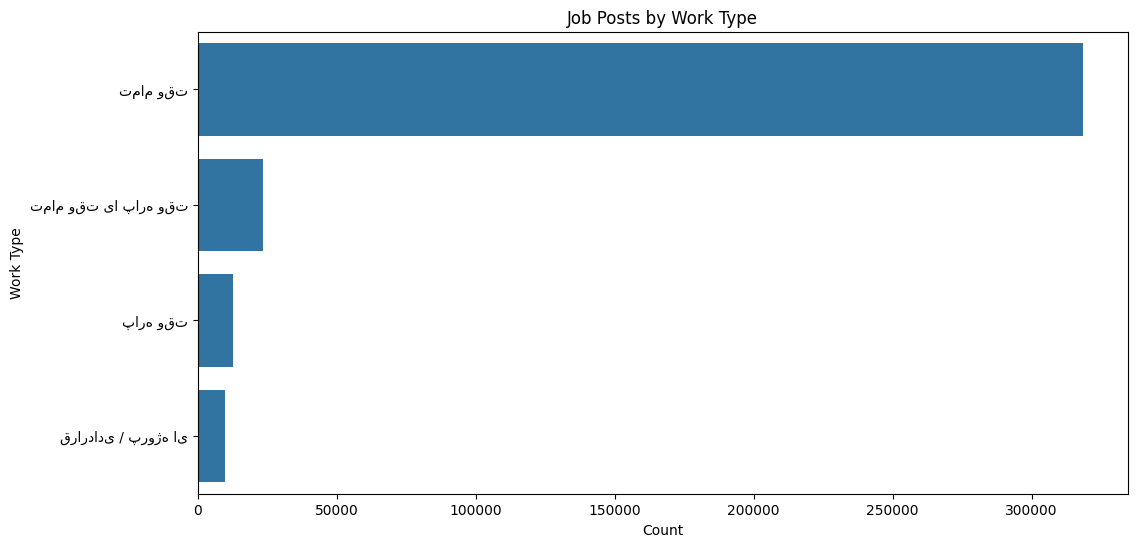

In [15]:
plt.figure(figsize=(12,6))
worktype_counts = df['Jobpost_WorkTypeFa'].value_counts()

sns.barplot(x=worktype_counts.values, y=worktype_counts.index)
plt.title("Job Posts by Work Type")
plt.xlabel("Count")
plt.ylabel("Work Type")
plt.show()


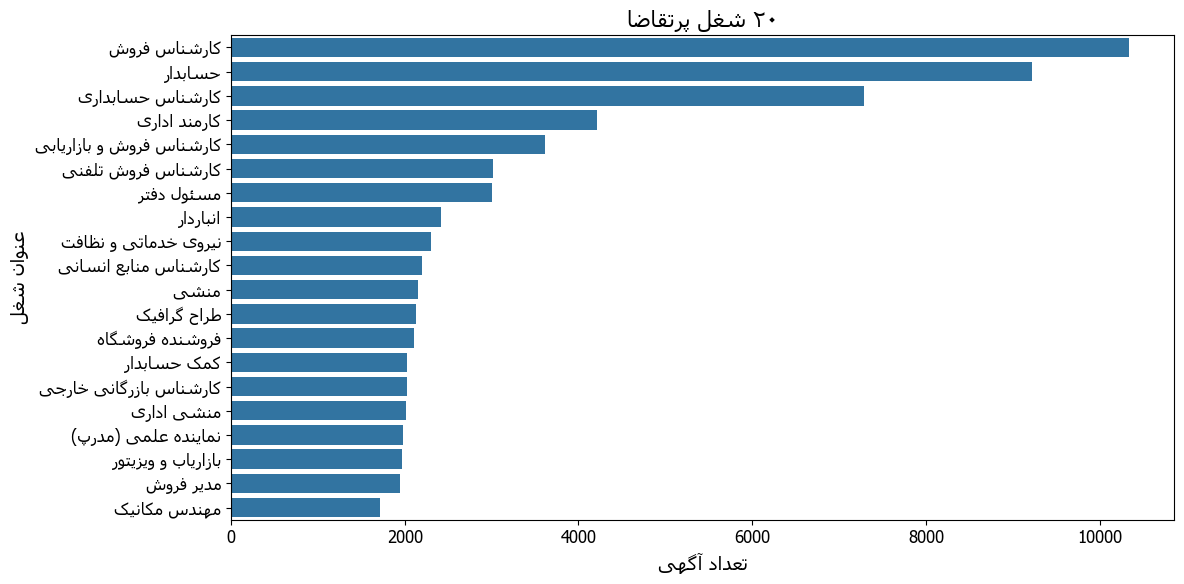

In [20]:
top_jobs = df['Jobpost_RawTitle_Clean'].value_counts().head(20)

xlabel = get_display(arabic_reshaper.reshape("تعداد آگهی"))
ylabel = get_display(arabic_reshaper.reshape("عنوان شغل"))
title = get_display(arabic_reshaper.reshape("۲۰ شغل پرتقاضا"))

plt.figure(figsize=(12,6))
sns.barplot(x=top_jobs.values, y=[get_display(arabic_reshaper.reshape(str(i))) for i in top_jobs.index])
plt.xlabel(xlabel, fontsize=14)
plt.ylabel(ylabel, fontsize=14)
plt.title(title, fontsize=16)
plt.tight_layout()
plt.show()



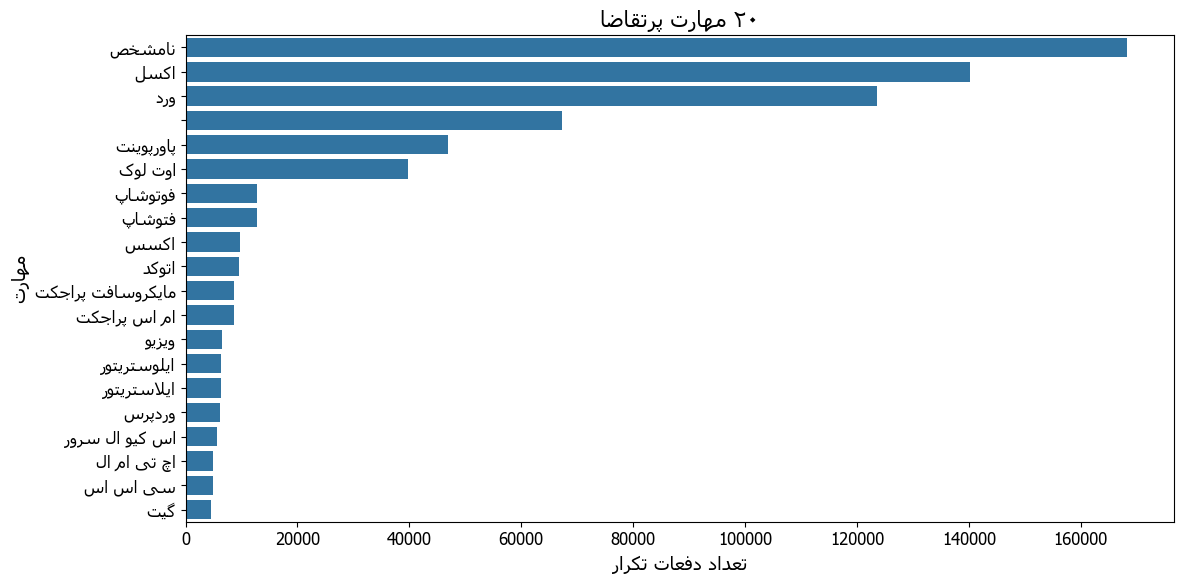

In [21]:
skills_series = df['all_skills'].dropna().str.split(',').explode().str.strip()
top_skills = skills_series.value_counts().head(20)

xlabel = get_display(arabic_reshaper.reshape("تعداد دفعات تکرار"))
ylabel = get_display(arabic_reshaper.reshape("مهارت"))
title = get_display(arabic_reshaper.reshape("۲۰ مهارت پرتقاضا"))

plt.figure(figsize=(12,6))
sns.barplot(x=top_skills.values, y=[get_display(arabic_reshaper.reshape(str(i))) for i in top_skills.index])
plt.xlabel(xlabel, fontsize=14)
plt.ylabel(ylabel, fontsize=14)
plt.title(title, fontsize=16)
plt.tight_layout()
plt.show()



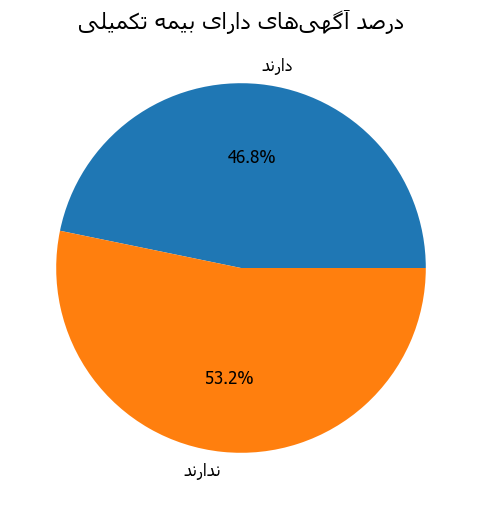

In [22]:
insurance_rate = df['بیمه تکمیلی'].mean() * 100

labels = [
    get_display(arabic_reshaper.reshape("دارند")),
    get_display(arabic_reshaper.reshape("ندارند"))
]

title = get_display(arabic_reshaper.reshape("درصد آگهی‌های دارای بیمه تکمیلی"))

plt.figure(figsize=(6,6))
plt.pie([insurance_rate, 100 - insurance_rate], labels=labels, autopct='%1.1f%%')
plt.title(title, fontsize=16)
plt.show()


خلاصه آماری ستون های غیر عددی...................................................................................................................................

In [10]:
df[categorical_cols].describe()

,Jobpost_RawTitle,Jobpost_PreferredGender,Jobpost_ProvinceFa,Jobpost_WorkTypeFa,Jobpost_SalaryCanBeShown,Jobpost_MainJobCategory,Jobpost_SecondaryJobCategories,Jobpost_IndustryFa,Jobpost_RequiredRelatedExperienceInThisIndustry,Jobpost_CompanyWorkTimesDescription,Jobpost_LanguageSkills,Jobpost_SoftwareSkills,Jobpost_AcademicFields,Jobpost_BenefitFa,Jobpost_HasDisabilitySupport,Jobpost_RequiredMilitaryServiceCard,Jobpost_IsRemote,Jobpost_IsInternship,Jobpost_PriorityWithLocalCandidate,Jobpost_ActivationTime_YEAR_MONTH,Company_AgeFromEstablishmentYear,Company_ProvinceFa,Company_CityFa,Comany_CompanyOwnershipTypesFa,Company_SizeFa,Company_SizeEn,Company_ActivityTypeFa,Company_IndustryFa,HasAcademicField,HasBenefit,Jobpost_RawTitle_Clean,Jobpost_RawTitle_Clean_Language,salary_status,Jobpost_Group,langs,levels_lang,first_skill,all_skills,all_skills_levels,academic,degree,همه_مزایا
count,364836,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,364838,329901,364838,364838,344383,359315,364838,364838,364838,364838
unique,57789,5,32,4,2,77,590,44,2,68247,397,49116,10249,30352,2,2,2,2,2,25,5,31,324,4,7,7,4,3561,2,2,60946,2,2,15,18,7,148,29187,2297,38,5,30352
top,کارشناس فروش,تفاوتی ندارد,تهران,تمام وقت,False,مالی و حسابداری,نامشخص,تولیدی / صنعتی,False,شنبه تا چهارشنبه,نامشخص,نامشخص,نامشخص,نامشخص,False,False,False,False,True,2023-10,more than 20 years,تهران,تهران,خصوصی,11 تا 50 نفر,11 - 50 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,تولیدی / صنعتی,False,True,کارشناس فروش,Farsi,توافقی,مالی و اداری,نامشخص,نامشخص,نامشخص,نامشخص,نامشخص,نامشخص,نامشخص,نامشخص
freq,10393,203147,235537,318659,244030,42863,283525,71350,283056,12238,235240,168264,193088,90938,348690,227336,339772,342741,193558,24017,207760,292012,279392,273039,94959,94959,146047,43848,193088,273900,10336,351975,244030,84292,235240,235240,168264,168264,168264,193088,193088,90938
